## O que é Análise de Regressão  

É uma técnica estatística que **identifica padrões** entre variáveis para responder:  
**"Quanto X influencia Y?"**

### Como funciona?  
- **Variável Y** (Dependente|Alvo|Target): O que queremos prever/explicar (ex: vendas).  
- **Variáveis X** (Independentes|Explicativas): Fatores que podem influenciar Y (ex: investimento em publicidade).  
- **Equação:** Gera uma "fórmula" (como `Y = 2,5 + 0,8X`) que mostra:  
  - **Efeito Direto:** Cada aumento em X eleva Y em 0,8 unidades.  
  - **Previsão:** Se X = 10, Y ≈ 10,5.  

### Para que serve?  
- Prever resultados futuros (ex: demanda de um produto).  
- Descobrir quais fatores mais impactam um resultado.  
- Tomar decisões baseadas em dados (ex: onde alocar recursos).  

**Exemplo Prático:**  
Se o preço de casas (Y) sobe R$ 15.000 para cada quarto adicional (X), o modelo revela essa relação quantificável, ajudando corretores e compradores a estimarem valores.  

### Chave do Sucesso:  
Não comprova causa e efeito definitivos, mas **revela associações** úteis para orientar estratégias com base em dados concretos.


## Tipos de Regressão: Quando Usar Cada Modelo
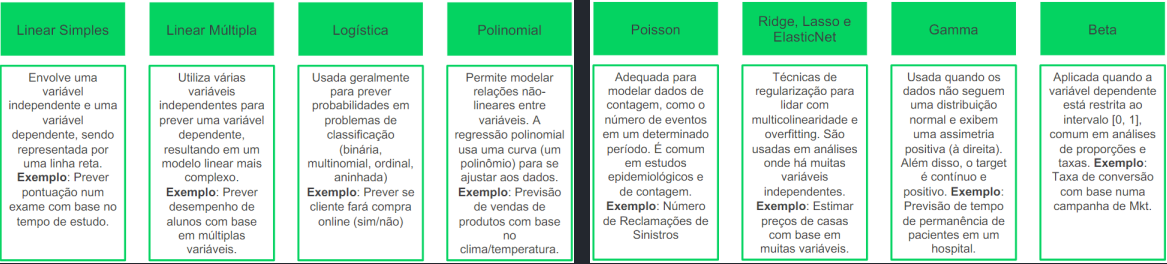

### 1. **Regressão Linear**  
- **Simples:**  
  Modela a relação entre **1 variável independente (X)** e **1 variável dependente contínua (Y)**.  
  *Exemplo:* Prever o preço de um imóvel com base no tamanho (m²).  

- **Múltipla:**  
  Usa **2+ variáveis independentes** para prever Y.  
  *Exemplo:* Vendas = β0 + β1(marketing) + β2(preço) + β3(estoque).  

---

### 2. **Regressão Logística**  
- **Binária:**  
  Prevê **2 categorias** (ex: sim/não).  
  *Exemplo:* Probabilidade de um cliente comprar um produto.  

- **Multinomial:**  
  Classifica **3+ categorias sem ordem** (ex: SUV, sedan, hatch).  
  *Exemplo:* Preferência de veículos por perfil socioeconômico.  

- **Ordinal:**  
  Classifica **categorias ordenadas** (ex: notas: ruim, médio, bom).  
  *Exemplo:* Satisfação de pacientes com atendimento hospitalar.  

---

### 3. **Regressão Polinomial**  
Modela relações **não lineares** com termos elevados (ex: \(Y = β0 + β1X + β2X^2\)).  
*Exemplo:* Crescimento de bactérias ao longo do tempo (curva exponencial).  

---

### 4. **Regressão Regularizada**  
- **Ridge e Lasso:**  
  Reduzem **multicolinearidade** e **overfitting** em modelos complexos.  
  *Exemplo:* Selecionar variáveis mais relevantes em dados com 100+ preditores.  

---

### 5. **Modelos Específicos**  
- **Poisson:**  
  Para **dados de contagem** (ex: número de acidentes por dia).  

- **Beta/Gama:**  
  Usados quando Y está em **intervalos limitados** (0 a 1) ou tem **distribuição assimétrica** (ex: renda familiar).  

---

### 🔑 Escolha o Modelo Certo:  
- **Dados contínuos?** → Regressão linear ou polinomial.  
- **Classificação categórica?** → Logística (binária/multinomial/ordinal).  
- **Muitas variáveis correlacionadas?** → Técnicas de regularização.  


## Processo da Regressão Linear Simples

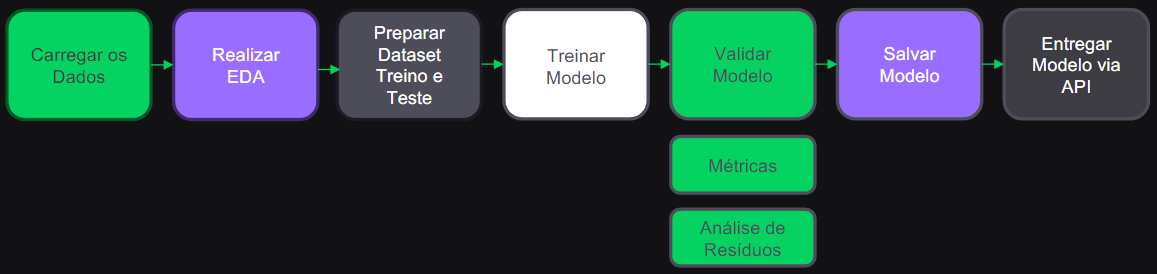

## Equação da Reta

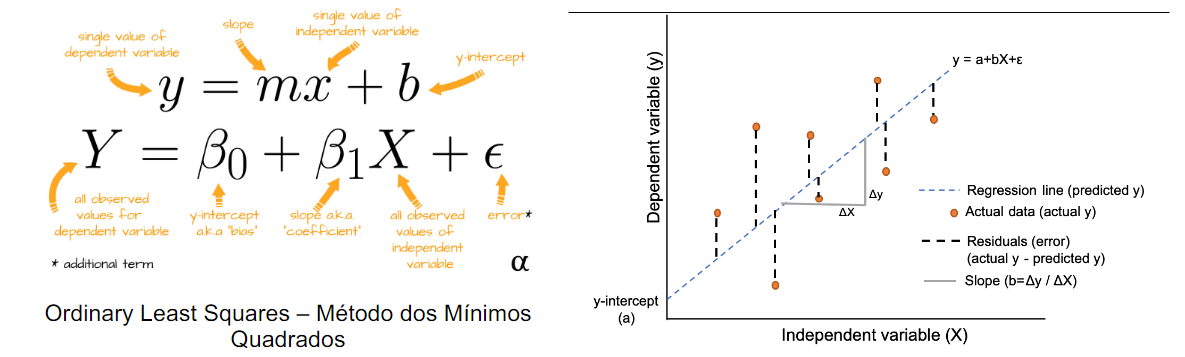

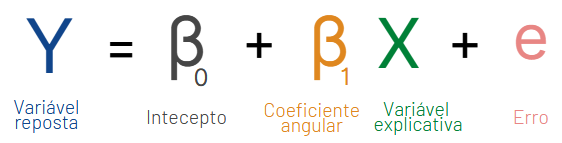

# Análise Exploratória de Dados (EDA)


## Importando as Bibliotecas

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from scipy.stats import shapiro, kstest, probplot, zscore
import pingouin as pg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Carga dos Dados
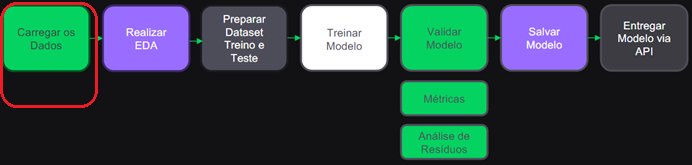

In [2]:
# Abrir o dataset
df_pontuacao = pd.read_csv('pontuacao_teste.csv')
df_pontuacao.head()

,horas_estudo,pontuacao_teste
0,1.1,30
1,2.0,55
2,2.5,60
3,3.6,75
4,4.2,85


In [3]:
# Informações DataFrame
df_pontuacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horas_estudo     101 non-null    float64
 1   pontuacao_teste  101 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


## 🔍 EDA para Regressão Linear Simples: **Passo a Passo**
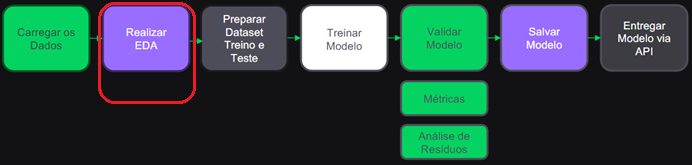

### 1. **Análise Estatística Básica**  
   - Calcule **média, mediana, desvio padrão** das variáveis.  
   *Exemplo:*  
   - Horas de estudo: Média = 35h, Desvio padrão = 4h  
   - Pontuação: Média = 72, Desvio = 8  

---

### 2. **Gráfico de Dispersão**  
   - Visualize a relação entre X (horas de estudo) e Y (pontuação).  
   - Identifique padrões:  
     
---

### 3. **Detecção de Outliers**  
- Use **boxplots** para verificar dados extremos:  

---

### 4. **Correlação Linear**  
- Calcule o **coeficiente de Pearson (r)** entre X e Y.  

---

### 5. **Distribuição das Variáveis**  
- Use **histogramas** ou **KDE plots**:  

---

### 📌 Conclusão do EDA:  
**Modelo Adequado?** ✅  
- Relação linear forte (r > 0.8) + sem outliers = Regressão Linear Simples é viável.  
- *Atenção:* A não linearidade perfeita sugere que termos polinomiais (ex: X²) podem melhorar o modelo futuramente.  

In [4]:
# Medidas Estatísticas das Variáveis
df_pontuacao.describe()

,horas_estudo,pontuacao_teste
count,101.000000,101.000000
mean,28.604950,455.000000
std,14.116128,221.385411
min,1.100000,30.000000
25%,16.500000,270.000000
50%,30.900000,465.000000
75%,41.800000,655.000000
max,46.900000,800.000000


In [5]:
# Mediana
df_pontuacao.median()

horas_estudo        30.9
pontuacao_teste    465.0
dtype: float64

<Axes: xlabel='horas_estudo', ylabel='pontuacao_teste'>

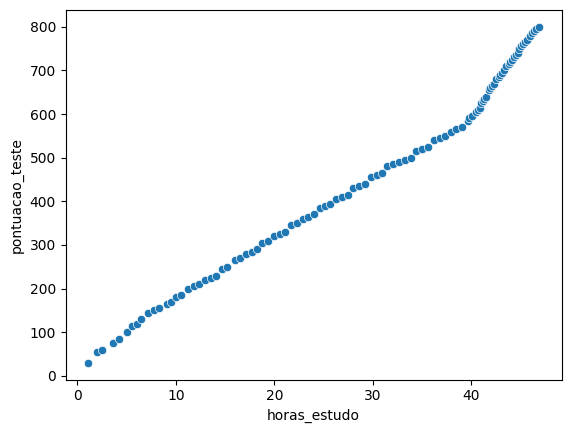

In [6]:
# Plot de Dispersão
# X = horas_estudo
# y = pontuacao_teste
sns.scatterplot(data=df_pontuacao, x='horas_estudo', y='pontuacao_teste')

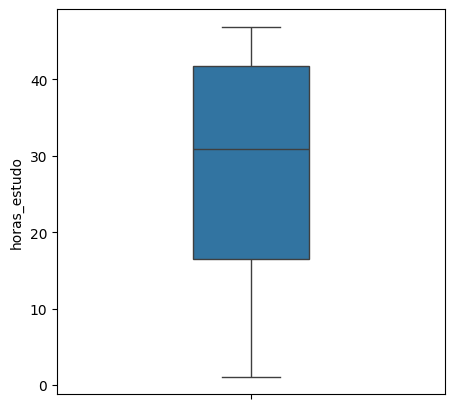

In [7]:
# Verificar se temos Outliers na Variável Independente X
ax = sns.boxplot(df_pontuacao, y='horas_estudo', width=0.3)
ax.figure.set_size_inches(5, 5)

<Axes: ylabel='pontuacao_teste'>

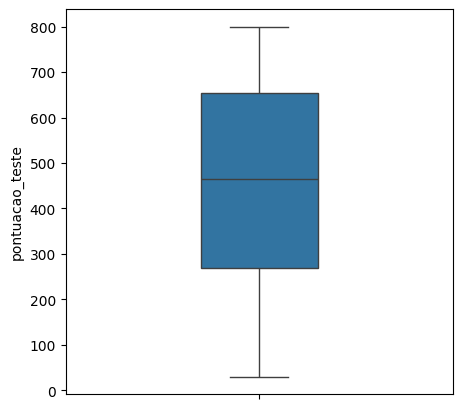

In [8]:
# Verificar se temos Outliers na Variável dependente y
ax = sns.boxplot(df_pontuacao, y='pontuacao_teste', width=0.3)
ax.figure.set_size_inches(5, 5)
ax

<Axes: >

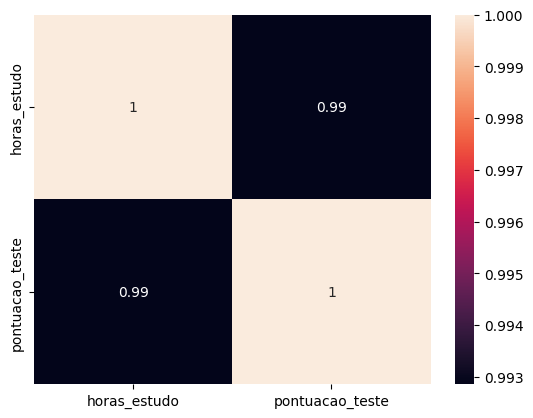

In [9]:
# Verificar Correlação - Pearson "Correlação Lineares"
sns.heatmap(df_pontuacao.corr('pearson'), annot=True)

<Axes: >

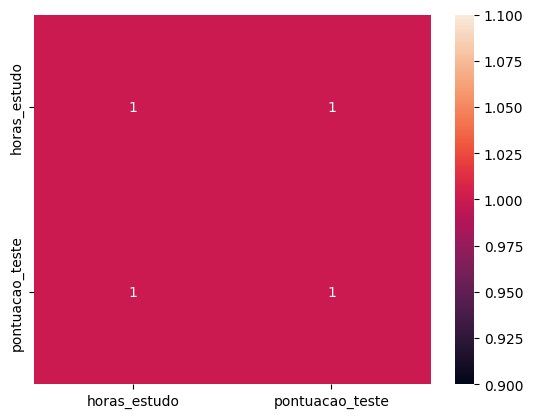

In [10]:
# Verificar Correlação - Spearman "Correlação não-lineares"
sns.heatmap(df_pontuacao.corr('spearman'), annot=True)

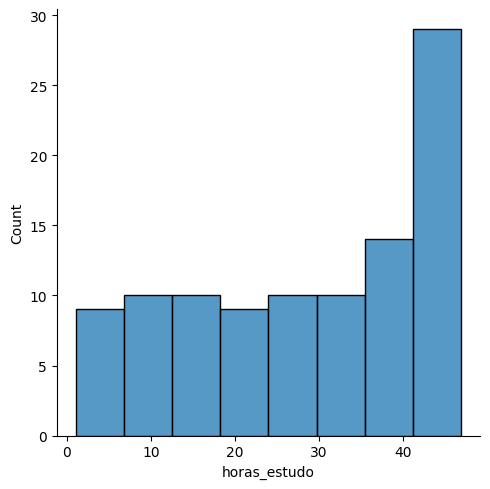

In [11]:
# Histograma das Variáveis independentes
sns.displot(df_pontuacao, x='horas_estudo')

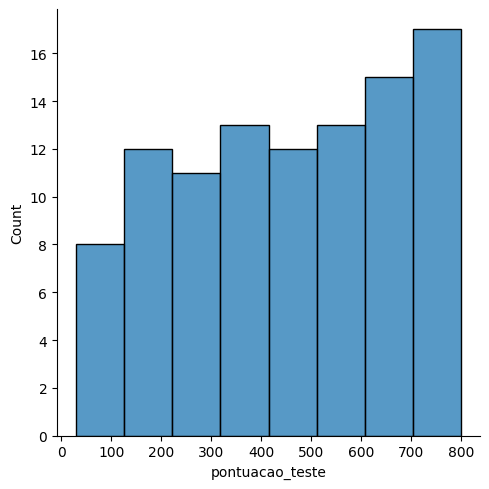

In [12]:
# Histograma das Variáveis dependentes
sns.displot(df_pontuacao, x='pontuacao_teste')

# 🚀 Treinamento do Modelo de Regressão Linear:
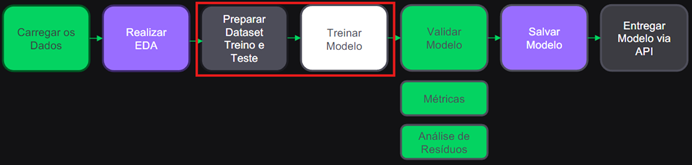

## **Dividir os Dados**  
   - Separe as variáveis:  
     - **X (Independente):** Horas de estudo.  
     - **Y (Dependente):** Pontuação no teste.  
   - Use `train_test_split` para criar conjuntos de **treino (70%)** e **teste (30%)**:  
     ```
     X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
     ```  

🔑 Por Que Dividir em Treino e Teste?  
- **Treino:** Ajusta o modelo aos dados conhecidos.  
- **Teste:** Avalia a precisão em dados não vistos (evita overfitting).

In [13]:
# reshape do pandas por ter apenas uma feature
X = df_pontuacao['horas_estudo'].values.reshape(-1, 1) # -1 Calcula automaticamente e o 1 é a quantidade de features, no caso 1 por ser simples.
y = df_pontuacao['pontuacao_teste'].values.reshape(-1, 1)

#Divisao em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## **Instanciar e Treinar o Modelo**  
   - Crie o modelo de regressão linear:  
     ```
     modelo = LinearRegression()
     ```  
   - Treine com os dados de treino:  
     ```
     modelo.fit(X_train, Y_train)
     ```  

---

In [14]:
# Instanciar o modelo a ser treinado
reg_model = LinearRegression()

# Treinar o modelo, para gerar uma relação entre essas duas variáveis (vai gerar o coeficiente e o intercept da reta)
reg_model.fit(X_train, y_train)

LinearRegression()

## **Entenda a Equação da Reta**  
   - Após o treino, o modelo gera:  
     - **Coeficiente Angular (β1):** "Peso" de X na previsão de Y.  
     - **Intercepto (β0):** Valor base de Y quando X = 0.  
   - Exemplo de equação:  
     ```
     print(f"Pontuação = {modelo.intercept_:.2f} + {modelo.coef_:.2f} * Horas_Estudo")
     ```  
     *Saída:* `Pontuação = 10.50 + 1.80 * Horas_Estudo`  

---

In [15]:
print(reg_model.coef_, reg_model.intercept_)

[[15.5981381]] [7.7535652]


In [15]:
# imprimir a equação da reta: y = aX + b
coef = reg_model.coef_[0][0]
intercept = reg_model.intercept_[0]
print("A equação da reta é: y = {:4f}X + {:4f}".format(coef, intercept))

A equação da reta é: y = 15.598138X + 7.753565


In [16]:
# Predição dos valores com base no conjunto de testes
y_pred = reg_model.predict(X_test)

# 📊 Validação do Modelo
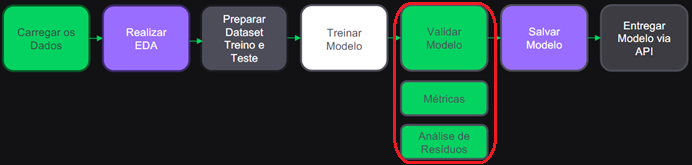

<font color= orange>**Métricas para Regressão:**</font> (R2, R-Squared ou Coeficiente de Determinação), MAE, MSEe RMSE

## R² (Coeficiente de Determinação) ou R-Squared 
- **O que mede:** <font color=orange>Proporção da variação de Y (Dependente) explicada por X (Independente) (0 a 1).</font>
- **Exemplo:** R² = 0.85 → 85% da variação na pontuação é explicada pelas horas de estudo.
- **Fórmula:**<br>
<font color=orange>R² = 1 - (Soma dos erros² / Soma total dos quadrados)</font>
---

In [17]:
# Comparar y_pred (predição) com o y_test (valor real para um determinado X)
r2_score(y_test, y_pred)

0.988458537799189

## MAE (Erro Absoluto Médio)  
<u>O MAE é menos sensivel aos outliers e fácil de interpretar</u>
- **O que mede:** <font color=orange>Média dos **erros absolutos** entre previsões e valores reais.</font>  
- **Vantagem:** Fácil de entender (ex: MAE = 3 → Erro médio de 3 pontos).  
- **Fórmula:**  
<font color=orange>MAE = Media (y_test - y_pred) / n</font>
---

In [18]:
# Calcular métrica MAE
mean_absolute_error(y_test, y_pred)

18.911466057520023

## MSE (Erro Quadrático Médio)  
- **O que mede:** <font color=orange>Média dos **erros ao quadrado**. </font> 
- **Vantagem:** Penaliza mais erros grandes (útil para detectar outliers).  
- **Desvantagem:** Unidade não intuitiva (ex: MSE = 25 → "pontos²").  
- **Fórmula:**  
<font color=orange>MSE = mean_squared_error(y_test - y_pred)2</font>

In [19]:
# Calcular métrica MSE
mean_squared_error(y_test, y_pred)

602.0734063884337

## RMSE (Raiz do Erro Quadrático Médio)  
- **O que mede:** <font color=orange>"Traduz" o MSE para a unidade original de Y.</font> 
- **Exemplo:** RMSE = 5 → Erro médio de 5 pontos.  
- **Fórmula:**  
<font color=orange>RMSE = √(MSE)</font>

In [20]:
# Calcular métrica RMSE
root_mean_squared_error(y_test, y_pred)

24.537184157690827

## **Análise Gráfica de Resíduos** 
### Testes Gráficos  
- **Gráfico de Dispersão (Reais vs. Previstos):**
- **Linearidade (Resíduos vs. Previstos):**  
- Resíduos entre **-2 e +2 (escala padrão)** → Modelo linear adequado.  
- *Exemplo de código:*  
  ```
  plt.scatter(y_pred, resíduos_padrão)
  plt.axhline(y=0, color='r', linestyle='--')
  ```  

- **Homocedasticidade:**  
- Resíduos **aleatórios** (sem padrão de "cone" ou "funil") → Variância constante.  
- Padrão identificado → **Heterocedasticidade** (modelo pode subestimar/sobrestimar em certos intervalos).  

---
### Homocedasticidade vs. Heterocedasticidade
Homocedasticidade e heterocedasticidade são conceitos estatísticos que se referem à variância dos erros em um modelo. 
#### <font color=lightblue>Homocedasticidade</font>
- A variância dos erros é constante
- Os resíduos têm variância constante
- Os resíduos são iguais em todas as variáveis independentes
- É uma suposição essencial em muitos métodos estatísticos, especialmente na regressão linear
#### <font color=lightblue>Heterocedasticidade</font>
- A variância dos erros é diferente para cada valor condicional de Xji 
- Os resíduos são observados com variância desigual 
- A variância condicional de Y varia com X 
- O tamanho do termo de erro difere em todo o valor da variável independente 

A heterocedasticidade pode ser causada por diversos fatores, como: Presença de outliers, Presença de variáveis omitidas, Especificação incorreta do modelo, Presença de relações não lineares entre as variáveis independentes e dependentes. 

A heterocedasticidade pode levar a inferências imprecisas e a testes de hipóteses que não são confiáveis. 

A heterocedasticidade compromete a eficiência dos estimadores e a validade dos testes de hipótese.

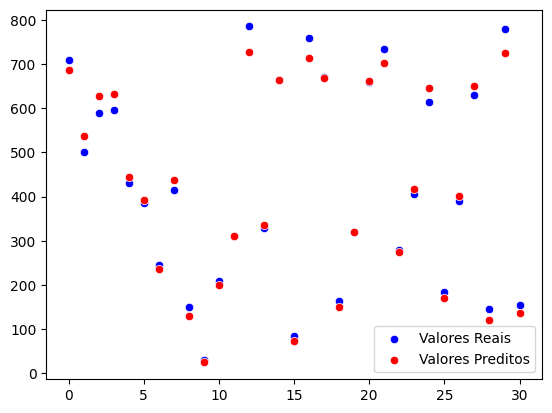

In [21]:
x_axis = range(len(y_test))
plt.Figure(figsize=(10,6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores Reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='red', label='Valores Preditos')
plt.legend()
plt.show()

## Padronização dos Resíduos  
- **Resíduo:** `y_test - y_pred`  
- **Escala Padrão (zscore):** `resíduo_padrão = (resíduo - média(resíduo)) / desvio_padrão(resíduo)`

In [ ]:
# Calcular Resíduos valor absoluto
residuos = y_test - y_pred

In [ ]:
# Calcular Resíduos escala padrão
# Converter os resíduos para uma escala padronizada (standardization)
# Para cada elemento de um conjunto (X - media) / desvio_padrao
residuos_std = zscore(residuos)

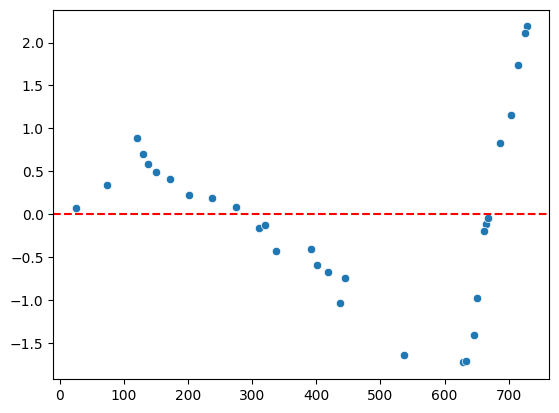

In [ ]:
# Primeira Validação Gráfica (Ver se há padrões que nos ajudam a fazer boas predições): Observaremos que estamos mais para um cenário de Heterocedasticidade ou homocedasticidade
sns.scatterplot(x=y_pred.reshape(-1), y=residuos_std.reshape(-1))
plt.axhline(y=0, color='r', linestyle='--')

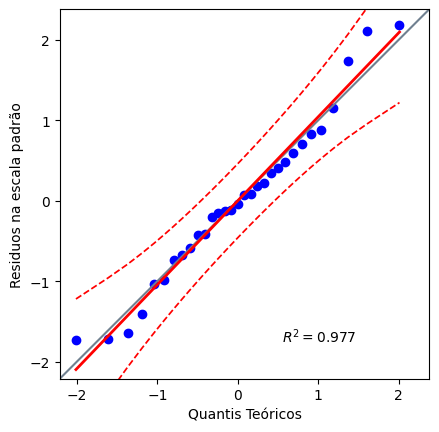

In [32]:
# Segunda Validação Gráfica (Se os Resíduos seguem uma distribuição normal)
# Gráfico QQ (Quantile-Quantile) plot, avalia se uma amostra segue uma distribuição normal
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teóricos')
plt.ylabel('Residuos na escala padrão')
plt.show()

## Teste de Normalidade de resíduos

### Shapiro-Wilk 
Verifica se os dados seguem uma distribuição normal.

**Características:**
- É especialmente adequado para amostras pequenas (n < 50).
- Tem maior poder estatístico comparado ao Kolmogorov-Smirnov, ou seja, é mais sensível na detecção de desvios da normalidade.
- Não exige que você especifique parâmetros da distribuição normal (média e desvio padrão), pois ele os estima a partir dos próprios dados.

**Hipóteses:**  
- H0 (hipótese nula): Os resíduos ou dados seguem distribuição normal.  
- H1 (hipótese alternativa): Os resíduos ou dados não seguem uma distribuição normal.  

**Interpretação do p-valor:**
- Se p-valor > 0,05 , não rejeitamos H0 (os dados seguem uma distribuição normal).
- Se p-valor ≤ 0,05 , rejeitamos H0 (os dados não seguem uma distribuição normal).

In [ ]:
# P-Valor = 0.53. Pelo teste de Shapiro Wilk, não rejeitamos o H0 e os resíduos seguem uma distribuição normal
stat_shapiro, p_valor_shapiro = shapiro(residuos.reshape(-1))
print('Estatística do teste: {} e P-Valor: {}'.format(stat_shapiro, p_valor_shapiro))

Estatística do teste: 0.9705965246814241 e P-Valor: 0.5356280271114633


### Kolmogorov-Smirnov  
Compara a distribuição empírica dos dados com uma distribuição teórica específica (por exemplo, a distribuição normal).

**Características:**
- Pode ser usado para amostras maiores.
- Requer que você especifique os parâmetros da distribuição teórica (média e desvio padrão). Caso contrário, o teste pode perder precisão.
- É menos poderoso que o Shapiro-Wilk, especialmente para amostras pequenas.

**Hipóteses:**
H0 (hipótese nula) : Os dados seguem a distribuição teórica especificada.
H1 (hipótese alternativa) : Os dados não seguem a distribuição teórica especificada.

**Interpretação do p-valor:**
- Se p-valor > 0,05 , não rejeitamos H0 (os dados seguem a distribuição especificada).
- Se p-valor ≤ 0,05 , rejeitamos H0 (os dados não seguem a distribuição especificada).

In [37]:
# P-Valor = 5.730989354927713e-08, essa notação científica é < que 0,05. Pelo teste de Shapiro Wilk P-Valor, rejeitamos o H0, por isso os resíduos não seguem uma distribuição normal
stat_ks, p_valor_ks = kstest(residuos.reshape(-1), 'norm')
print('Estatística do teste: {} e P-Valor: {}'.format(stat_ks, p_valor_ks))

Estatística do teste: 0.5088903067746836 e P-Valor: 5.730989354927713e-08


### Outras Considerações: Shapiro-Wilks e Kolmogorov-Smirnov
- Validação cruzada K-fold : Uma técnica útil para melhorar a robustez do modelo, dividindo os dados em subconjuntos e validando o modelo em diferentes partições.
- Obtenção de mais dados : Aumentar o tamanho da amostra pode ajudar a reduzir incertezas e melhorar a qualidade do modelo.
- Consulta a especialistas : Validar o modelo com profissionais do domínio do problema pode fornecer insights valiosos sobre variáveis adicionais ou ajustes necessários.

### Tabela Comparativa
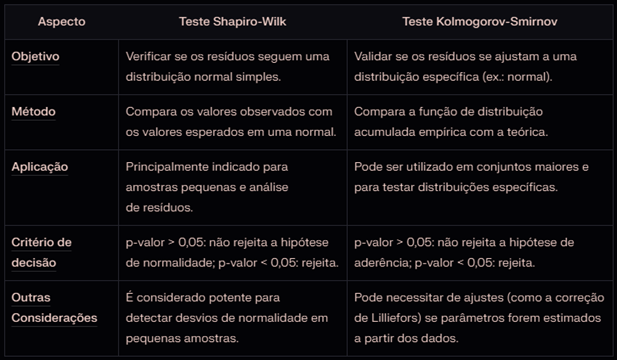

## 📊 Fazendo Previsões com o Modelo de Regressão

###  Pontuação prevista
Use a equação do modelo para estimar Y com base em X:

**Interpretação:**  
- 30.4 horas de estudo → Pontuação estimada de **481.42**.  
- *Aplicação prática:* Planejamento de estudos para alcançar metas acadêmicas.

In [82]:
# Se eu estudar 30.4 horas, qual pontuação prevista pelo modelo (y)?
reg_model.predict([[30.4]])

array([[481.93696332]])

### Calcular Horas Necessárias (X)
Inverta a equação para descobrir quanto X é necessário para atingir um Y desejado:

**Implicações:**  
- Para 600 pontos, são necessárias **37.97 horas** de estudo.  
- *Atenção:* Valores extremos podem indicar extrapolação não confiável do modelo.  

In [83]:
# Fazendo o contrário: Quero tirar 600 pontos (pelo modelo), quantas horas (x) tenho que estudar?
# Equação da Reta: y = ax + b 
#                 ax = y - b
#                  x = (y - b)/a
((600-reg_model.intercept_[0])/reg_model.coef_[0][0])

np.float64(37.96904676399677)

### Salvar o Modelo Treinado
Armazene o modelo para reutilização sem retreinamento:

In [84]:
joblib.dump(reg_model, './modelo_regressao.pkl')

['./modelo_regressao.pkl']

### Executar a api
- <font color=yellow>Terminal:</font> uvicorn api_modelo_regressao:app --reload
- <font color=yellow>Navegador:</font> Swagger http://127.0.0.1:8000/docs